<a href="https://colab.research.google.com/github/bagasajaa19/praktikumML1/blob/main/bagasProjek1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iterasi 1
Centroid 1: [41. 19.] | Centroid 2: [ 47. 100.]
Iterasi 2
Centroid 1: [33.4 33.8] | Centroid 2: [ 44.6 122.6]
Iterasi 3
Centroid 1: [34.83333333 38.83333333] | Centroid 2: [ 45.25 137.25]

Iterasi 4: Tidak ada perubahan cluster. Selesai.


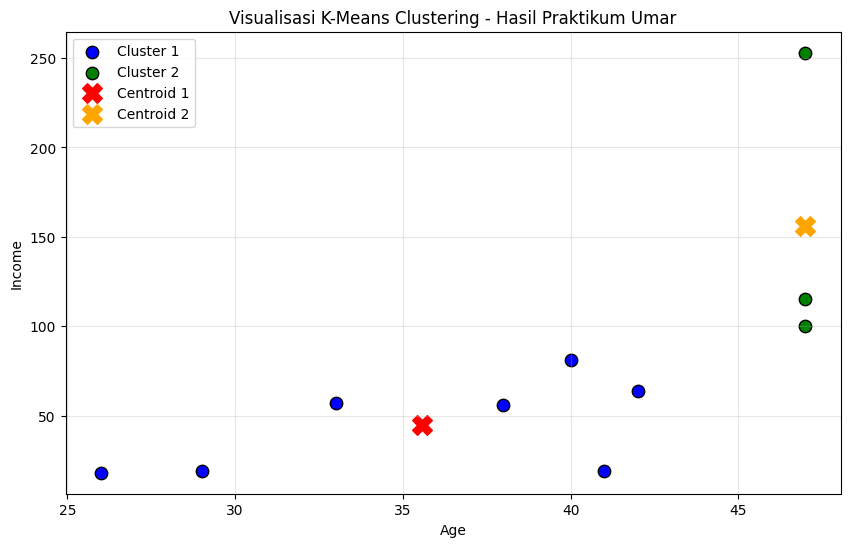


Tabel Hasil Akhir:
   CustID  Age  Income  Cluster
0       1   41      19        1
1       2   47     100        2
2       3   33      57        1
3       4   29      19        1
4       5   47     253        2
5       6   40      81        1
6       7   38      56        1
7       8   42      64        1
8       9   26      18        1
9      10   47     115        2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Inisialisasi Dataset
bagas_data = {
    'CustID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age': [41, 47, 33, 29, 47, 40, 38, 42, 26, 47],
    'Income': [19, 100, 57, 19, 253, 81, 56, 64, 18, 115]
}

bagas_df = pd.DataFrame(bagas_data)

# 2. Centroid Awal
bagas_c1 = np.array([41.0, 19.0])
bagas_c2 = np.array([47.0, 100.0])

def hitung_jarak(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def proses_kmeans_bagas(df, c1, c2):
    iterasi = 1
    while True:
        jarak_c1 = []
        jarak_c2 = []
        klaster_list = []

        # Hitung Jarak ke Centroid
        for i in range(len(df)):
            titik = df.iloc[i][['Age', 'Income']].values
            d1 = hitung_jarak(titik, c1)
            d2 = hitung_jarak(titik, c2)

            jarak_c1.append(d1)
            jarak_c2.append(d2)
            klaster_list.append(1 if d1 < d2 else 2)

        # Cek apakah ada perubahan (Konvergensi)
        if iterasi > 1 and np.array_equal(klaster_list, df['Cluster'].values):
            print(f"\nIterasi {iterasi}: Tidak ada perubahan cluster. Selesai.")
            break

        df['Jarak ke C1'] = jarak_c1
        df['Jarak ke C2'] = jarak_c2
        df['Cluster'] = klaster_list

        print(f"Iterasi {iterasi}")
        print(f"Centroid 1: {c1} | Centroid 2: {c2}")

        # Update Centroid untuk iterasi selanjutnya
        c1 = df[df['Cluster'] == 1][['Age', 'Income']].mean().values
        c2 = df[df['Cluster'] == 2][['Age', 'Income']].mean().values
        iterasi += 1

    return df, c1, c2

# Jalankan fungsi
bagas_hasil, bagas_final_c1, bagas_final_c2 = proses_kmeans_bagas(bagas_df, bagas_c1, bagas_c2)

# --- VISUALISASI ---
plt.figure(figsize=(10, 6))

# Plot Data berdasarkan Cluster
for k in [1, 2]:
    cluster_data = bagas_hasil[bagas_hasil['Cluster'] == k]
    warna = 'blue' if k == 1 else 'green'
    plt.scatter(cluster_data['Age'], cluster_data['Income'], c=warna, label=f'Cluster {k}', s=80, edgecolors='black')

# Plot Centroid Akhir
plt.scatter(bagas_final_c1[0], bagas_final_c1[1], c='red', marker='X', s=200, label='Centroid 1')
plt.scatter(bagas_final_c2[0], bagas_final_c2[1], c='orange', marker='X', s=200, label='Centroid 2')

plt.title('Visualisasi K-Means Clustering - Hasil Praktikum Bagas')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tampilkan Tabel Akhir
print("\nTabel Hasil Akhir:")
print(bagas_hasil[['CustID', 'Age', 'Income', 'Cluster']])